# Feature Importance

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

FEATURES = ['delta', 'fragility_score', 'variance']
ELOS = list(range(1000, 2000, 100))

In [62]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.tail()

,fen,next_move,games_count,global_avg_elo,global_winrate,engine_move,delta,fragility_score,variance,group_count_1000,...,historical_best_1700,is_historical_best_1700,group_count_1800,winrate_1800,historical_best_1800,is_historical_best_1800,group_count_1900,winrate_1900,historical_best_1900,is_historical_best_1900
265,rnbqkb1r/pp2pp1p/5np1/3p2B1/3P4/2N2N2/PPP2PPP/...,f8g7,104,1678.096154,0.451923,b8c6,0.116353,0.048808,-0.428462,9.0,...,[f8g7],True,63,0.444444,[f8g7],True,56,0.428571,[f8g7],True
266,rnbqkb1r/pp3ppp/4pn2/1B1p4/3P4/2N2N2/PPP2PPP/R...,c8d7,110,1599.345455,0.518182,c8d7,0.366785,0.667710,-0.324725,24.0,...,[c8d7],True,49,0.551020,[c8d7],True,45,0.533333,[c8d7],True
267,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,210,1564.290476,0.485714,b8c6,0.295233,0.063857,-0.464949,37.0,...,[f8e7],True,114,0.456140,[f8e7],True,98,0.469388,[f8e7],True
268,rnbqkb1r/pp3ppp/4pn2/3p2B1/3P4/2N2N2/PPP2PPP/R...,f8e7,102,1590.254902,0.480392,b8c6,0.259457,0.063857,-0.446934,16.0,...,[f8e7],True,60,0.500000,[f8e7],True,44,0.477273,[f8e7],True
269,rnbqkbnr/pp3ppp/4p3/3pP3/3P4/5N2/PP3PPP/RNBQKB...,b8c6,103,1590.407767,0.466019,b8c6,0.116353,-0.760091,-0.446039,18.0,...,[b8c6],True,58,0.568966,[b8c6],True,49,0.489796,[b8c6],True


## Analyze feature importance

In [63]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances

,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900
delta,0.305362,0.350838,0.354250,0.285470,0.358230,0.382289,0.281855,0.381419,0.295741,0.343297
fragility_score,0.350504,0.295630,0.359087,0.322444,0.331877,0.334052,0.344504,0.316510,0.327698,0.340404
variance,0.344135,0.353532,0.286663,0.392086,0.309893,0.283660,0.373641,0.302071,0.376561,0.316299


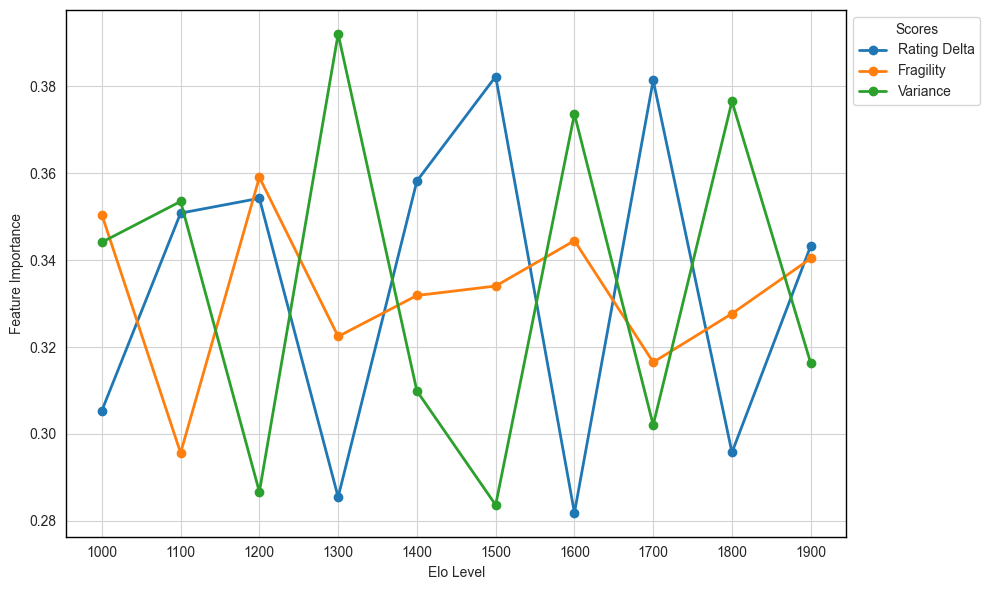

In [64]:
# Create a figure for the smoothed feature importances
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    ax.plot(ELOS, y, marker='o', linewidth=2, label=feature_labels.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

ax.set_xlabel("Elo Level")
ax.set_ylabel("Feature Importance")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Scores",
    facecolor="white"
)

fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()

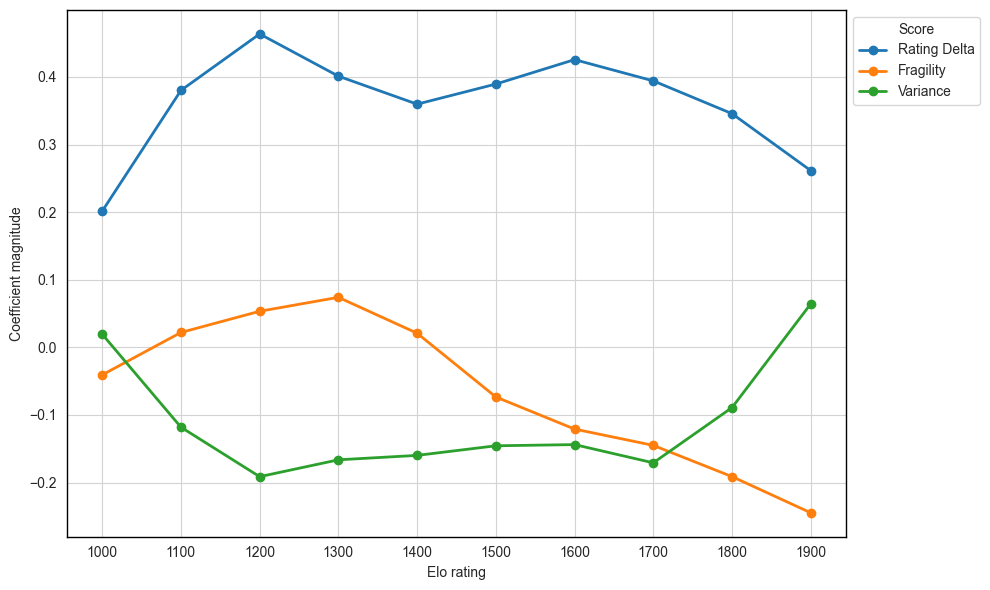

In [65]:
coefficients = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)
    coefficients[f'elo_{elo}'] = model.coef_[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}

for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(ELOS, y_smooth, marker='o', linewidth=2, label=feature_labels.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Coefficient magnitude")
plt.xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_coefficients.pdf")
plt.show()

## Compute score and recommend a move

In [66]:
for elo in ELOS:
    score_col = f"score_{elo}"
    rec_col = f"recommended_move_{elo}"
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    elo_col = f"elo_{elo}"
    group_count_col = f"group_count_{elo}"
    hist_col = f"historical_best_{elo}"

    # Compute score
    df[score_col] = (
            coefficients.loc["delta", elo_col] * df["delta"] +
            coefficients.loc["fragility_score", elo_col] * df["fragility_score"] +
            coefficients.loc["variance", elo_col] * df["variance"]
    )

    # Determine the recommended move per FEN based on the score
    idx_best_score = df.groupby("fen")[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best_score, ["fen", "next_move"]].set_index("fen")["next_move"]
    df[rec_col] = df["fen"].map(recommended)

    # Compare recommendations and engine move with historical best
    df[is_best_col] = df.apply(lambda r: r[rec_col] in r[hist_col], axis=1).astype('boolean')
    df[is_engine_col] = df.apply(lambda r: r["engine_move"] in r[hist_col], axis=1).astype('boolean')

    # Mask out positions with too few samples or missing data
    invalid_mask = (
            (df[group_count_col] < 20) |
            (df[group_count_col].isna())
    )
    df.loc[invalid_mask, [is_best_col, is_engine_col]] = pd.NA

    # Exclude rows where engine move is not among the observed moves for that position
    valid_moves_per_fen = df.groupby("fen")["next_move"].agg(set).to_dict()
    df["engine_valid_move"] = df.apply(
        lambda row: row["engine_move"] in valid_moves_per_fen.get(row["fen"], set()),
        axis=1
    )
    df.loc[~df["engine_valid_move"], [is_engine_col]] = pd.NA
    df.drop(columns="engine_valid_move", inplace=True)

In [67]:
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'


# TEST

In [68]:
results = []
grouped = df.groupby("fen").first().reset_index()


def weighted_mean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return float("nan")
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()


for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    group_count_col = f"group_count_{elo}"

    weighted_avg_is_best = weighted_mean(grouped[is_best_col], grouped[group_count_col])
    weighted_avg_is_engine_best = weighted_mean(grouped[is_engine_col], grouped[group_count_col])

    results.append({
        "elo": elo,
        "avg_is_best": weighted_avg_is_best,
        "avg_is_engine_best": weighted_avg_is_engine_best
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_engine_best
elo,,
1000,0.816773,0.754506
1100,0.877700,0.827689
1200,0.903099,0.841050
1300,0.905352,0.800748
1400,0.887073,0.830780
1500,0.886476,0.846983
1600,0.887255,0.857595
1700,0.880618,0.839040
1800,0.887226,0.847505


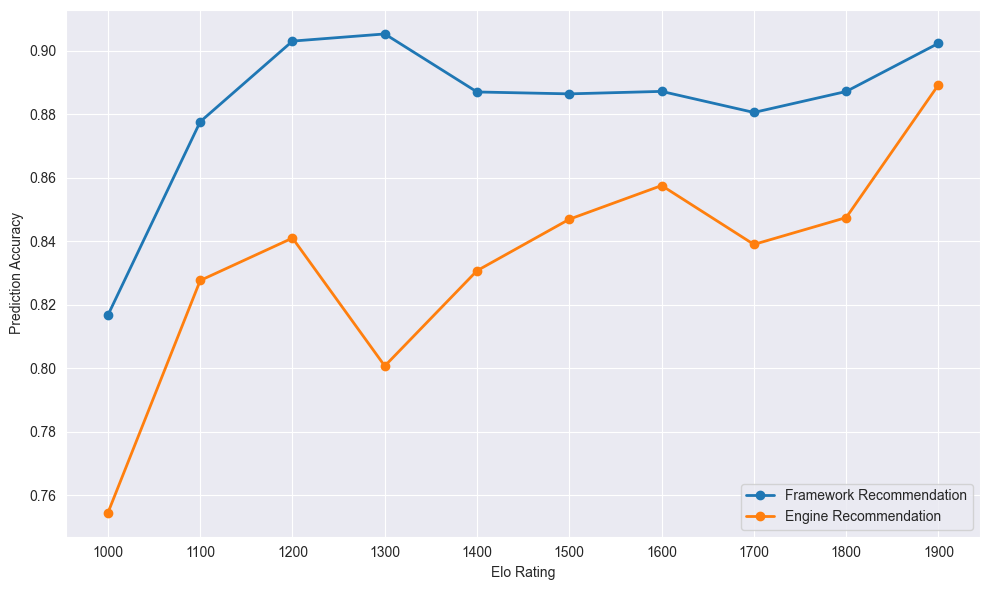

In [69]:
plt.figure(figsize=(10, 6))

for col in results.columns:
    if col == "avg_is_best":
        label = "Framework Recommendation"
    else:
        label = "Engine Recommendation"
    plt.plot(results.index, results[col].values, marker='o', linewidth=2, label=label)

plt.xlabel("Elo Rating")
plt.ylabel("Prediction Accuracy")
plt.xticks(results.index)
plt.legend()
plt.tight_layout()
plt.savefig("../images/prediction_accuracy.svg")
plt.show()

# stacked linechart

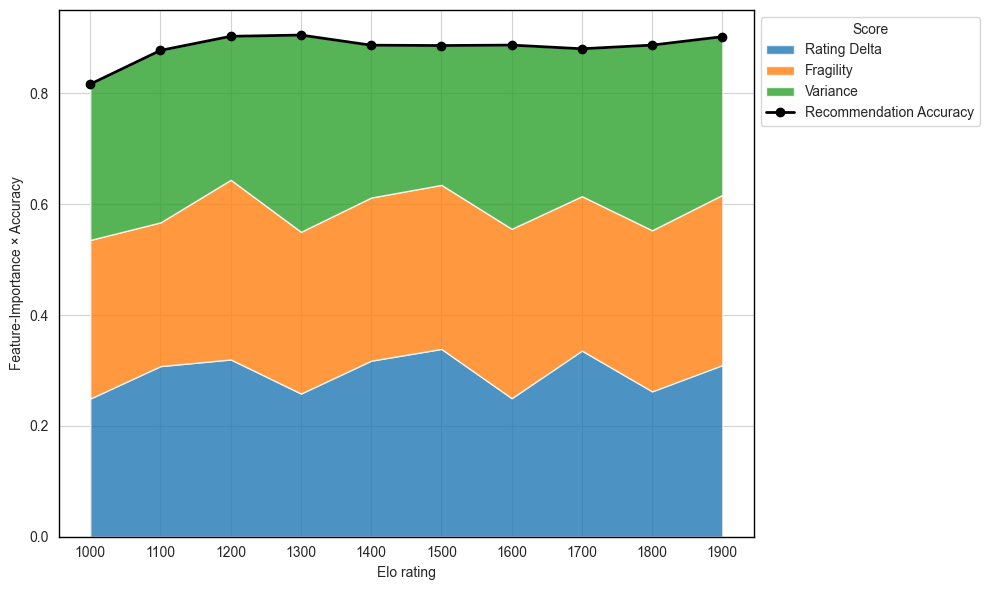

In [70]:
import matplotlib.pyplot as plt
import re

# 1. Spaltennamen von 'importances' in Integer-Elo umwandeln,
#    falls sie das Format "elo_1000", "elo_1100" o. Ä. haben.
#    Beispiel: "elo_1000" → 1000
if importances.columns.dtype == object:
    importances.columns = (
        importances.columns
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 2. Index von 'results' ebenfalls in Integer-Elo umwandeln,
#    falls er z. B. "elo_1000", "elo_1100" o. Ä. enthält.
if results.index.dtype == object:
    results.index = (
        results.index
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 3. Transponiere 'importances', sodass jede Zeile eine Elo-Stufe ist,
#    und reindexiere auf dieselben Elo-Werte wie 'results'.
fi_df = importances.T.reindex(results.index).fillna(0)

# 4. Hole die Framework-Accuracy („avg_is_best“) als Array
y_acc = results["avg_is_best"].reindex(fi_df.index).fillna(0).values

# 5. Berechne für jedes Feature den Beitrag: feature_importance × accuracy
feature_arrays = []
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}
for feat in FEATURES:
    arr = fi_df[feat].values * y_acc
    feature_arrays.append(arr)

# 6. Zeichne das gestapelte Flächen-Diagramm unterhalb der Accuracy-Linie
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

ax.stackplot(
    fi_df.index,
    *feature_arrays,
    labels=[feature_labels[f] for f in FEATURES],
    alpha=0.8
)
ax.plot(
    fi_df.index,
    y_acc,
    color="black",
    marker="o",
    linewidth=2,
    label="Recommendation Accuracy"
)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Feature-Importance × Accuracy")
ax.set_xticks(fi_df.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()